# Phase 1 — Consumer perception of green onion genotypes

Analysis of the consumer survey *"Decisión de compra de cebolla de rama: cuéntanos tu opinión"* for ten green onion (*Allium fistulosum* and hybrid) genotypes.

| Panel | Analysis | Survey sheet |
|---|---|---|
| a) | Likert (1–5) ratings of visual attributes | `Preguntas por material` |
| b) | Purchase intention by genotype (No / Maybe / Yes) | `Preguntas por material` |
| c) | Acceptance curve derived from the *"stop purchasing"* question | `Preguntas por material` |
| d) | Acceptance curve from direct selection at each timepoint | `Preguntas en vida util` |
| e) | Acceptance heatmap, balanced panel (fixed n) | `Preguntas en vida util` |

**Input:** `data/Phase_1_Consumer_perception.xlsx`. Sheet names, column names and answer labels (`"No"`, `"Tal vez"`, `"Sí"`) are kept exactly as they appear in the Spanish survey export.

All figures share the same size and resolution (300 dpi), white background, closed axes and Times New Roman. Figures are shown inline and are not written to disk.

## 1. Setup

In [1]:
import re
import difflib
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# "png" works best with right click > Copy Image in VS Code.
# Avoid "retina": it looks sharper but breaks copy/paste.
%matplotlib inline
%config InlineBackend.figure_format = "png"

# Silence font-manager warnings
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

# --- Font: Times New Roman only ---
# Declare the family as "serif" and pick the serif face separately. Putting the
# name directly in font.family (or a fallback list) triggers
# "findfont: Font family ... not found" warnings.
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams["mathtext.rm"] = "Times New Roman"
plt.rcParams["mathtext.it"] = "Times New Roman:italic"
plt.rcParams["mathtext.bf"] = "Times New Roman:bold"

# --- Sizes ---
plt.rcParams["font.size"] = 13
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 11

# --- Closed axes (all 4 spines) ---
for side in ["top", "right", "left", "bottom"]:
    plt.rcParams[f"axes.spines.{side}"] = True
plt.rcParams["axes.linewidth"] = 0.9

# --- White background ---
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"

# --- HD: 300 dpi for every figure ---
plt.rcParams["figure.dpi"] = 300

# --- Single figure size shared by all plots ---
FIGSIZE = (8, 6)

# --- Paths: run from the repository root or from notebooks/ ---
ROOT = Path.cwd() if (Path.cwd() / "data").is_dir() else Path.cwd().parent
SURVEY_PATH = ROOT / "data" / "Phase_1_Consumer_perception.xlsx"


def close_axes(ax):
    """Full frame (all 4 spines visible)."""
    for side in ["top", "right", "left", "bottom"]:
        ax.spines[side].set_visible(True)


def legend_outside(ax, title=None, ncol=1):
    """Legend outside the plotting area, on the right."""
    ax.legend(title=title, bbox_to_anchor=(1.02, 1), loc="upper left",
              borderaxespad=0, frameon=False, ncol=ncol)


def palette(n, name, reverse=False):
    """n hex colors sampled uniformly from a colormap."""
    cmap = matplotlib.colormaps[name]
    colors = [matplotlib.colors.to_hex(cmap(p)) for p in np.linspace(0.08, 0.92, n)]
    return colors[::-1] if reverse else colors


# --- Likert colors ---
# reverse=False -> level 1 RED and level 5 BLUE (negative = warm)
# reverse=True  -> level 1 BLUE and level 5 RED
# Diverging options: RdYlBu, RdBu, BrBG, PuOr, PiYG, Spectral, coolwarm, RdYlGn
LIKERT_COLORS = palette(5, "RdYlBu", reverse=False)     # levels 1..5
PURCHASE_COLORS = palette(3, "RdYlBu", reverse=False)   # No, Maybe, Yes

## 2. Genotypes: fixed colors and markers

The G code sets the order of the curves and the color/marker of each genotype. Only the genotype name is shown in the figures.

In [1]:
GENOTYPES = {
    "G1":  {"genotype": "CUNSBR048", "color": "#CDCD00", "marker": "*"},
    "G2":  {"genotype": "91400070",  "color": "#2CA02C", "marker": "^"},
    "G3":  {"genotype": "ANTSNC003", "color": "#9B59B6", "marker": "v"},
    "G4":  {"genotype": "91400028",  "color": "#1A78C2", "marker": "o"},
    "G5":  {"genotype": "NDSCAR038", "color": "#17BECF", "marker": ">"},
    "G6":  {"genotype": "91400035",  "color": "#FF8000", "marker": "s"},
    "G7":  {"genotype": "ANTSON013", "color": "#7B3F00", "marker": "P"},
    "G8":  {"genotype": "ANTSRO029", "color": "#E91E8C", "marker": "X"},
    "G9":  {"genotype": "91400071",  "color": "#D62728", "marker": "D"},
    "G10": {"genotype": "ANTSRO030", "color": "#808080", "marker": "p"},
}

## 3. Load the `Preguntas por material` sheet and match columns

Column names contain extra spaces and `?2` suffixes, so questions are matched with regular expressions.

The sheet also holds rows from a separate survey that only rated some visual attributes (no per-genotype questions). Only respondents of the per-genotype survey are kept, so every item in the figures shares the same respondent base.

In [2]:
df_all = pd.read_excel(SURVEY_PATH, sheet_name="Preguntas por material")

purchase_cols = [c for c in df_all.columns if c.startswith("Would you buy")]
shelf_life_cols = [c for c in df_all.columns if "stop purchasing" in c]

df = df_all[df_all[purchase_cols].notna().any(axis=1)].reset_index(drop=True)
print(f"Rows in sheet: {len(df_all)}  |  Respondents of the per-genotype survey: {len(df)}\n")

blocks = {}
for c in purchase_cols:
    material = re.search(r"Would you buy\s+(\S+)\s+material", c).group(1)
    blocks[material] = {"purchase": c}
for c in shelf_life_cols:
    material = re.search(r"stop purchasing\s+(.+?)\s*\?", c).group(1).strip()
    blocks[material]["shelf_life"] = c


def build_style(blocks, genotypes=GENOTYPES, cutoff=0.75, verbose=True):
    """Map each material name in the Excel file -> {G code, order, color, marker}.

    1) Match by exact name.
    2) Anything left unmatched is searched by similarity and REPORTED.
    3) Warn about any material left without a style.

    This works regardless of how the genotype code was typed in the Excel
    file, without hiding the differences.
    """
    style, pending = {}, {}
    for g, info in genotypes.items():
        name = info["genotype"]
        if name in blocks:
            style[name] = {"g": g, "order": int(g[1:]),
                           "color": info["color"], "marker": info["marker"]}
        else:
            pending[g] = info

    unassigned = [m for m in blocks if m not in style]
    report = []
    for g, info in list(pending.items()):
        candidates = difflib.get_close_matches(info["genotype"], unassigned, n=1, cutoff=cutoff)
        if candidates:
            m = candidates[0]
            style[m] = {"g": g, "order": int(g[1:]),
                        "color": info["color"], "marker": info["marker"]}
            unassigned.remove(m)
            report.append((g, info["genotype"], m))
            del pending[g]

    if verbose:
        n_exact = len(genotypes) - len(report) - len(pending)
        print(f"Materials in the Excel file : {len(blocks)}")
        print(f"Exact matches               : {n_exact}/{len(genotypes)}")
        for g, expected, found in report:
            print(f"  APPROXIMATE: {g} '{expected}' -> Excel '{found}'   <-- CHECK")
        if pending:
            print(f"  UNMATCHED (in GENOTYPES, not in the Excel file): "
                  f"{[i['genotype'] for i in pending.values()]}")
        if unassigned:
            print(f"  Excel materials WITHOUT an assigned style: {unassigned}")
        if not report and not pending and not unassigned:
            print("  Everything matches exactly. Nothing to check.")
    return style


STYLE = build_style(blocks)

Rows in sheet: 188  |  Respondents of the per-genotype survey: 59

Materials in the Excel file : 10
Exact matches               : 10/10
  Everything matches exactly. Nothing to check.


## 4. Plotting functions (Likert and classic acceptance curve)

In [3]:
def frequency_table(df, columns, labels, levels):
    """Item x level DataFrame with the % of responses at each level."""
    rows = []
    for col in columns:
        r = df[col].dropna()
        n = len(r)
        row = {"item": labels[col], "n": n}
        for level in levels:
            row[level] = 100 * (r == level).sum() / n
        rows.append(row)
    return pd.DataFrame(rows).set_index("item")


def diverging_likert(table, levels, colors, title=None, panel_label=None,
                     legend_title="Response", figsize=FIGSIZE,
                     legend_labels=None, row_order=None):
    """Diverging Likert chart. Works with 5 levels (1-5) or 3 (No/Maybe/Yes).

    The middle level is split half and half around zero.
    row_order: list with the desired row order. If None, rows are sorted by % positive.
    """
    table = table.copy()
    mid = len(levels) // 2
    negatives, neutral, positives = levels[:mid], levels[mid], levels[mid + 1:]

    if row_order is not None:
        table = table.loc[row_order]
    else:
        table["_pos"] = table[list(positives)].sum(axis=1)
        table = table.sort_values("_pos", ascending=False)

    color_of = dict(zip(levels, colors))
    neutral_half = table[neutral].values / 2

    fig, ax = plt.subplots(figsize=figsize)

    left = -neutral_half.copy()                                 # negative side
    for level in reversed(negatives):
        v = table[level].values
        left = left - v
        ax.barh(table.index, v, left=left, color=color_of[level],
                edgecolor="white", linewidth=0.7)

    ax.barh(table.index, table[neutral].values, left=-neutral_half,   # neutral centered on zero
            color=color_of[neutral], edgecolor="white", linewidth=0.7)

    right = neutral_half.copy()                                 # positive side
    for level in positives:
        v = table[level].values
        ax.barh(table.index, v, left=right, color=color_of[level],
                edgecolor="white", linewidth=0.7)
        right = right + v

    # % labels on both sides and in the center
    total_neg = table[list(negatives)].sum(axis=1).values
    total_pos = table[list(positives)].sum(axis=1).values
    edge_left = -(neutral_half + total_neg)
    edge_right = neutral_half + total_pos
    for yi, (el, er, ng, nu, ps) in enumerate(
            zip(edge_left, edge_right, total_neg, table[neutral].values, total_pos)):
        ax.text(el - 2, yi, f"{ng:.0f}%", ha="right", va="center",
                fontsize=10, color="#333333")
        ax.text(er + 2, yi, f"{ps:.0f}%", ha="left", va="center",
                fontsize=10, color="#333333")
        ax.text(0, yi, f"{nu:.0f}%", ha="center", va="center",
                fontsize=9, color="#1a1a1a")

    lim = max(edge_right.max(), -edge_left.min()) + 16
    ax.set_xlim(-lim, lim)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(50))
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{abs(x):.0f}"))
    ax.set_xlabel("Percentage")
    ax.invert_yaxis()
    # Zero line: without a gray panel it anchors the reading
    ax.axvline(0, color="#666666", linewidth=0.8, zorder=0)

    if title:
        ax.set_title(title)
    if panel_label:
        ax.annotate(panel_label, xy=(0, 1.02), xycoords="axes fraction",
                    fontsize=15, fontweight="bold")

    close_axes(ax)

    labels = legend_labels or [str(n) for n in levels]
    handles = [plt.Rectangle((0, 0), 1, 1, color=color_of[n], ec="white") for n in levels]
    ax.legend(handles, labels, title=legend_title, bbox_to_anchor=(1.02, 1),
              loc="upper left", borderaxespad=0, frameon=False)
    fig.tight_layout()
    return fig, ax


def acceptance_curve(df, blocks, answer_filter, mode, timepoints=(1, 2, 3, 4)):
    """% of respondents who would still buy each material at each timepoint."""
    curves, ns = {}, {}
    for material, cols in blocks.items():
        sub = df if answer_filter is None else df[df[cols["purchase"]].isin(answer_filter)]
        r = sub[cols["shelf_life"]].dropna()
        n = len(r)
        ns[material] = n
        if mode == "exclusive":
            curves[material] = [100 * (r > j).sum() / n for j in timepoints]
        else:
            curves[material] = [100 * (r >= j).sum() / n for j in timepoints]
    curve = pd.DataFrame(curves, index=[f"T{j}" for j in timepoints]).T
    return curve, pd.Series(ns)


def plot_curve(curve, ns, timepoints, style=None, title=None, panel_label=None,
               figsize=FIGSIZE, show_n=False):
    """Acceptance curve with the fixed color and marker of each genotype.

    Curves follow the G code order (G1..G10); the legend shows ONLY the
    genotype name.
    """
    style = STYLE if style is None else style
    order = sorted(curve.index,
                   key=lambda m: style[m]["order"] if m in style else 999)

    fig, ax = plt.subplots(figsize=figsize)
    for material in order:
        s = style.get(material, {"color": "#000000", "marker": "o"})
        label = f"{material} (n={ns[material]})" if show_n else material
        ax.plot(timepoints, curve.loc[material].values,
                marker=s["marker"], color=s["color"],
                linewidth=1.8, markersize=7,
                markeredgecolor="white", markeredgewidth=0.6,
                label=label)

    ax.set_xticks(timepoints)
    ax.set_xticklabels([f"T{j}" for j in timepoints])
    ax.set_xlim(0.85, max(timepoints) + 0.15)
    ax.set_ylim(-3, 103)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.set_xlabel("Timepoint")
    ax.set_ylabel("Respondents still willing to buy (%)")

    if title:
        ax.set_title(title)
    if panel_label:
        ax.annotate(panel_label, xy=(0, 1.02), xycoords="axes fraction",
                    fontsize=15, fontweight="bold")

    close_axes(ax)
    legend_outside(ax, title="Genotype")
    fig.tight_layout()
    return fig, ax

## 5. a) Likert ratings (1–5) of visual attributes

                      n     1     2     3     4     5
item                                                 
Pseudostem color     59   0.0   1.7  22.0  33.9  42.4
Leaves color         59   1.7   3.4  22.0  40.7  32.2
Pseudostem length    59   3.4   3.4  13.6  47.5  32.2
Pseudostem diameter  59   1.7   5.1  16.9  42.4  33.9
Leaves length        59  11.9  25.4  33.9  18.6  10.2


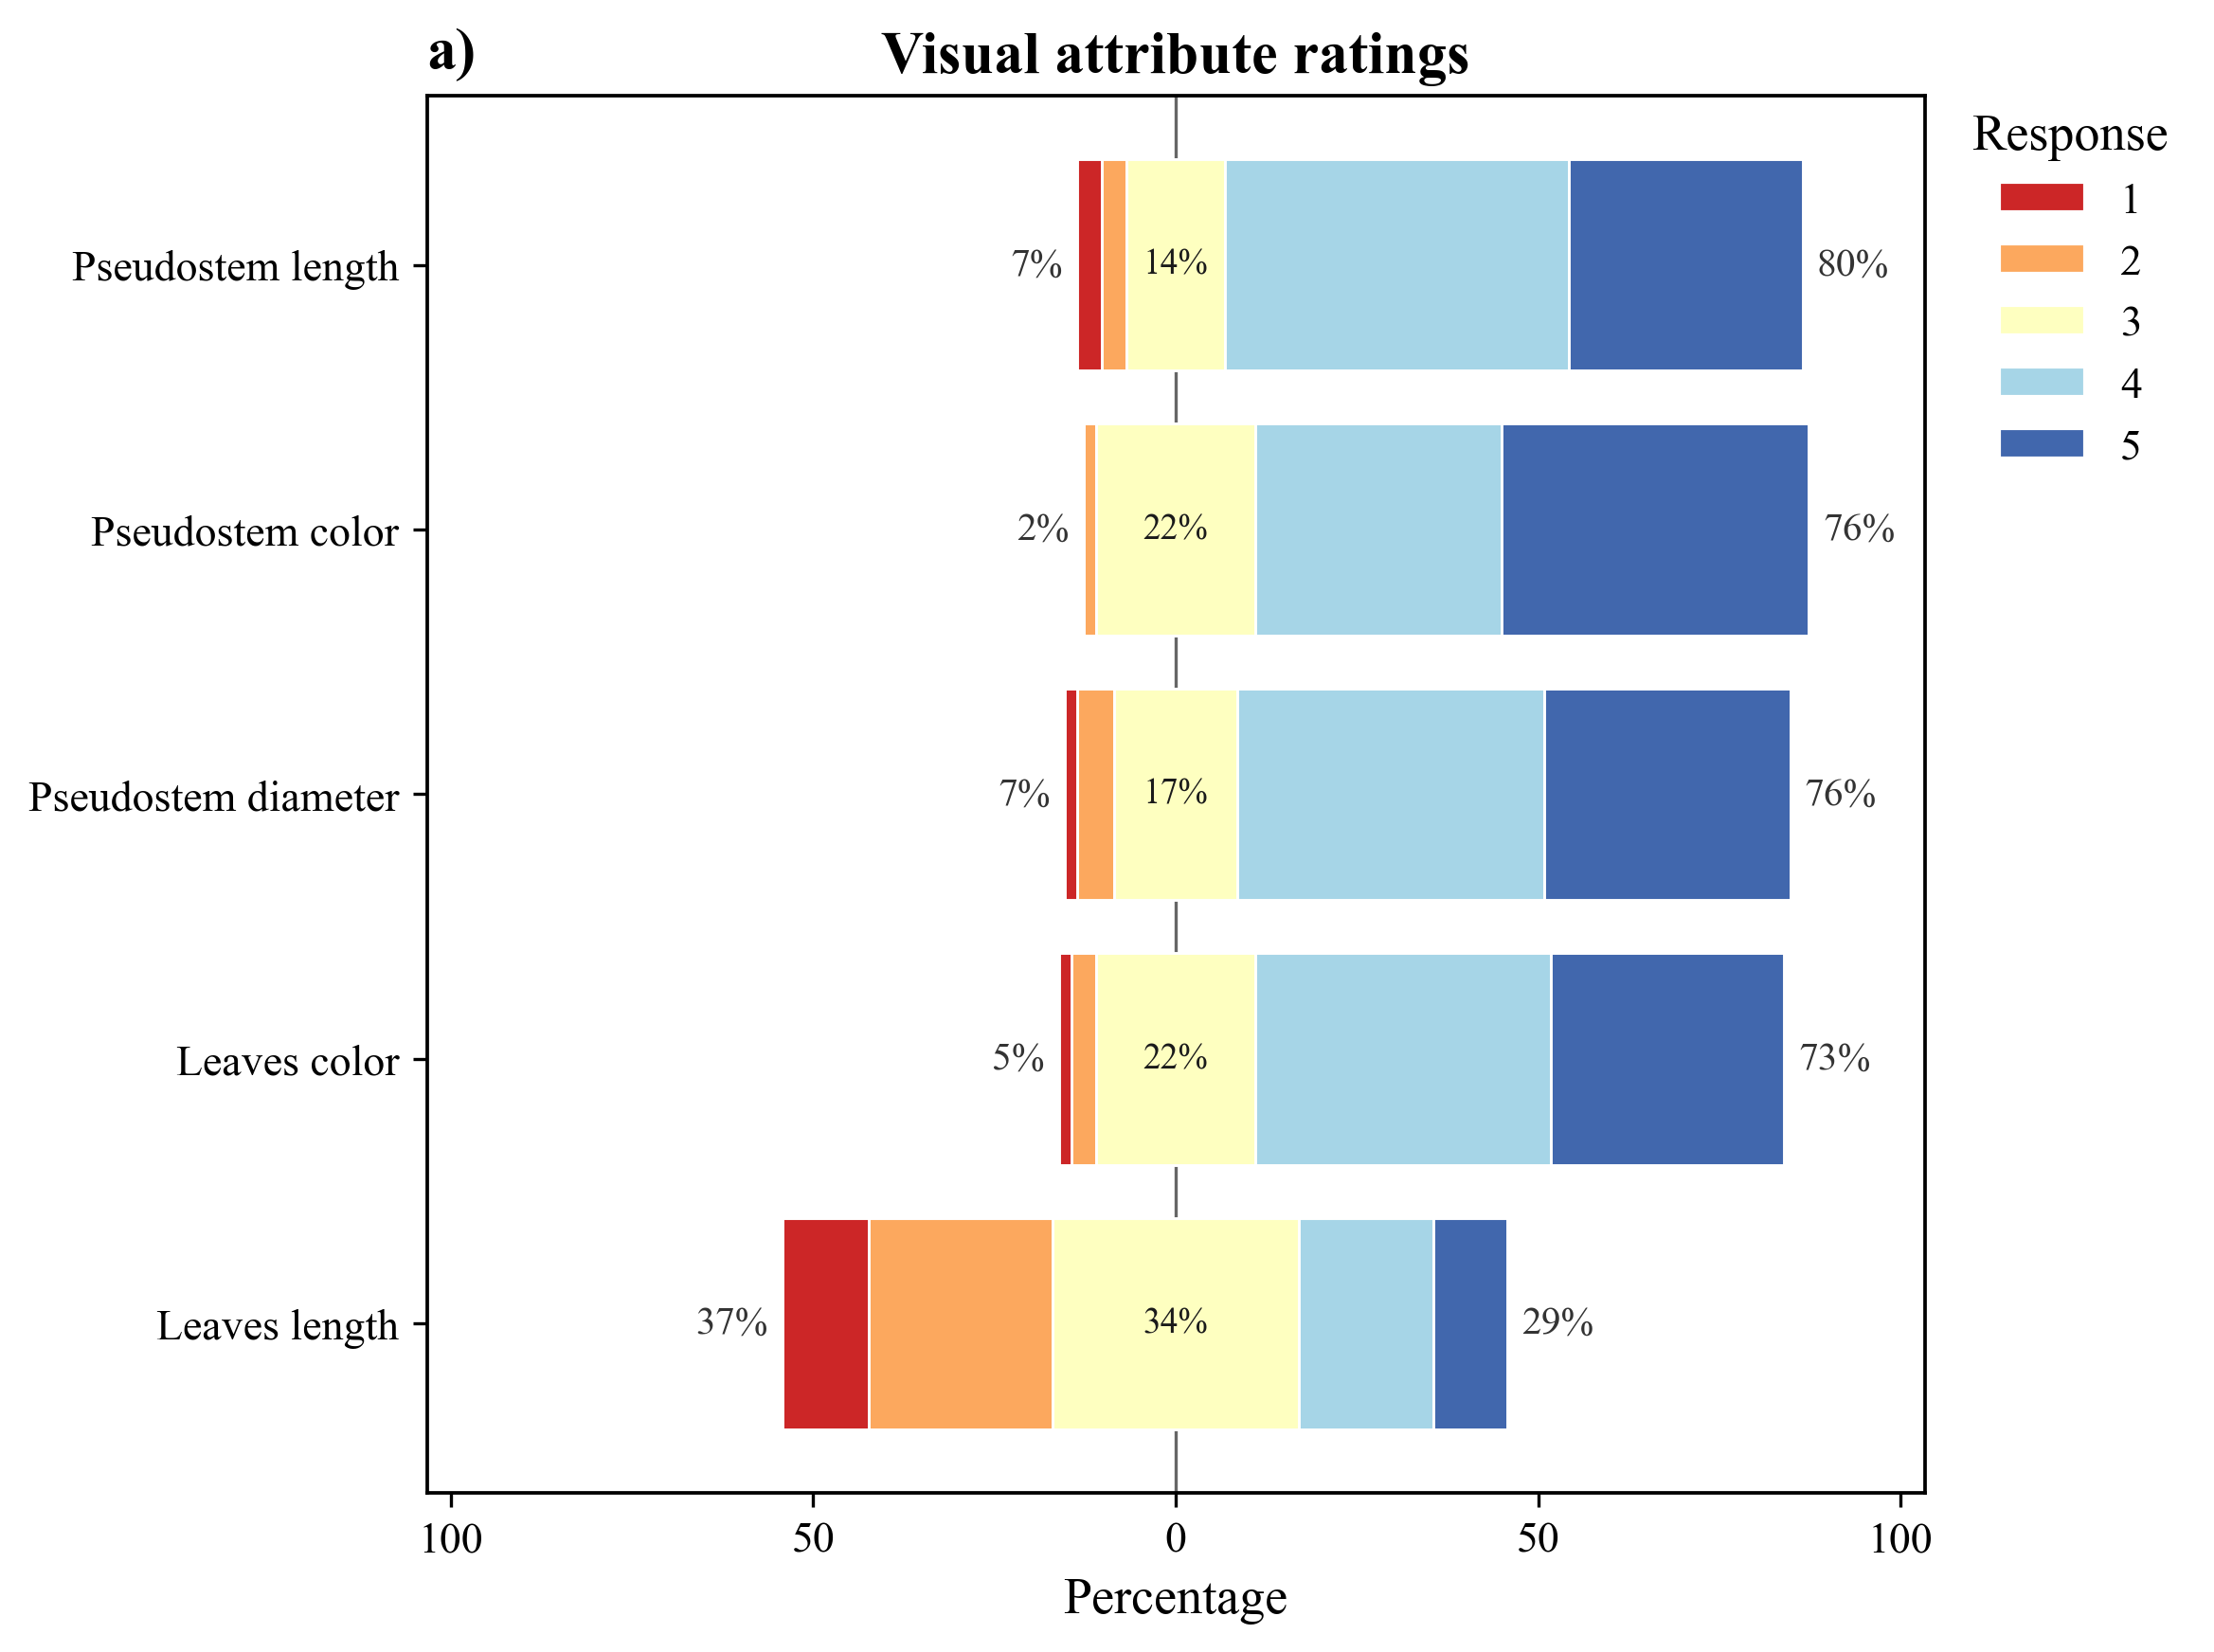

In [4]:
LIKERT_COLS = ["Pseudosteam color", "Leaves color", "Pseudosteam Length",
               "Pseudosteam diameter", "Leaves length"]
LIKERT_LABELS = {
    "Pseudosteam color": "Pseudostem color",
    "Leaves color": "Leaves color",
    "Pseudosteam Length": "Pseudostem length",
    "Pseudosteam diameter": "Pseudostem diameter",
    "Leaves length": "Leaves length",
}
LIKERT_LEVELS = [1, 2, 3, 4, 5]

likert_pct = frequency_table(df, LIKERT_COLS, LIKERT_LABELS, LIKERT_LEVELS)
print(likert_pct.round(1))

fig_a, _ = diverging_likert(
    likert_pct, LIKERT_LEVELS, LIKERT_COLORS,
    title="Visual attribute ratings",
    panel_label="a)",
    legend_title="Response",
)
plt.show()

## 6. b) Purchase intention by genotype

            n    No  Tal vez    Sí
item                              
CUNSBR048  59  47.5     35.6  16.9
91400070   59  22.0     39.0  39.0
ANTSNC003  59  16.9     23.7  59.3
91400028   59  25.4     28.8  45.8
NDSCAR038  59  15.3     37.3  47.5
91400035   59  15.3     23.7  61.0
ANTSON013  59  39.0     33.9  27.1
ANTSRO029  59   8.5     10.2  81.4
91400071   59   6.8     25.4  67.8
ANTSRO030  59  20.3     37.3  42.4


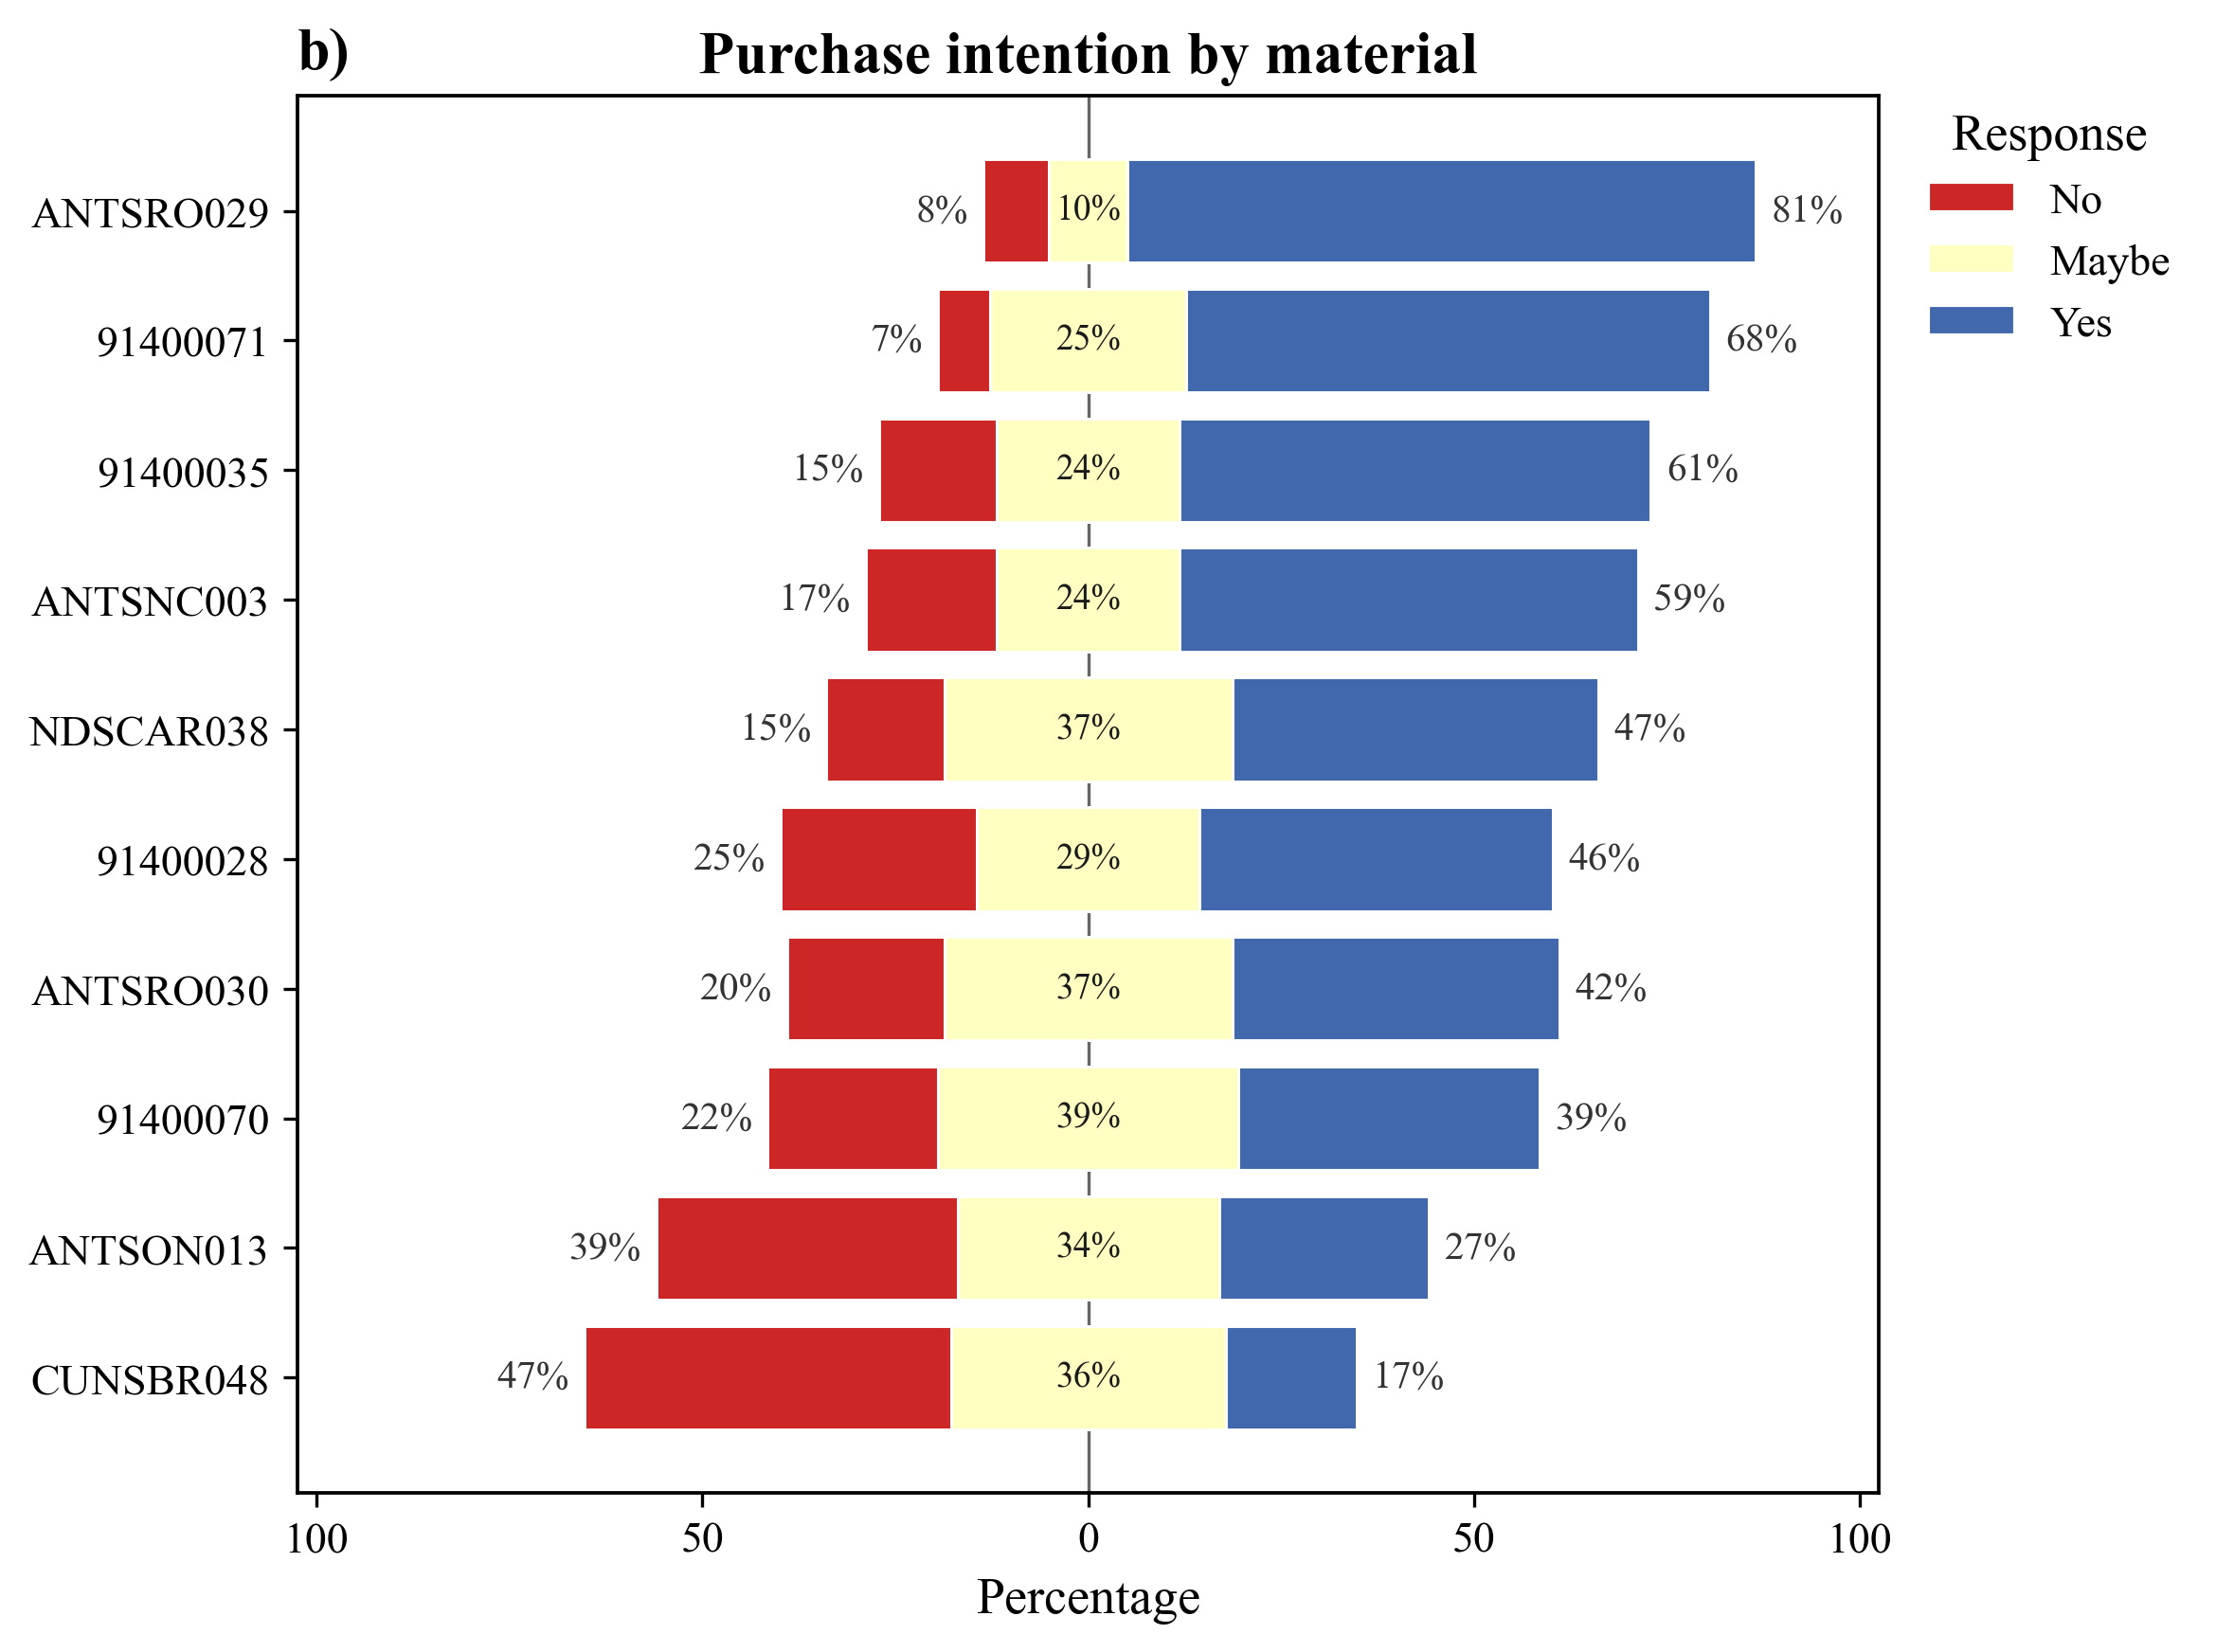

In [5]:
purchase_labels = {c: re.search(r"Would you buy\s+(\S+)\s+material", c).group(1)
                   for c in purchase_cols}
PURCHASE_LEVELS = ["No", "Tal vez", "Sí"]   # exactly as stored in the survey (No / Maybe / Yes)

purchase_pct = frequency_table(df, purchase_cols, purchase_labels, PURCHASE_LEVELS)
print(purchase_pct.round(1))

# PURCHASE_ORDER: None -> sort by % Yes (recommended, reads as a ranking).
# For G1..G10 order use instead:
#   PURCHASE_ORDER = sorted(purchase_pct.index, key=lambda m: STYLE[m]["order"])
PURCHASE_ORDER = None

fig_b, _ = diverging_likert(
    purchase_pct, PURCHASE_LEVELS, PURCHASE_COLORS,
    title="Purchase intention by material",
    panel_label="b)",
    legend_title="Response",
    legend_labels=["No", "Maybe", "Yes"],
    row_order=PURCHASE_ORDER,
)
plt.show()

## 7. c) Classic acceptance curve (derived from *"stop purchasing"*)

Parameters:

- **`SHELF_LIFE_FILTER`** — which respondents are included:
  - `["Sí", "Tal vez"]` → only those who would consider buying the material (recommended).
  - `["Sí"]` → only those who would buy it (stricter, low n).
  - `None` → all respondents (includes inconsistent answers; not recommended).
- **`CURVE_MODE`** — how the answer *"stop = k"* is read (choose according to the actual wording of the form):
  - `"exclusive"` → *"from T_k on I no longer buy it"* ⇒ accepted at T_j if k > j (T4 is 0% for all).
  - `"inclusive"` → *"T_k is the LAST one I buy"* ⇒ accepted at T_j if k ≥ j (T1 is 100% for all).

The n per genotype is printed below the curve table (needed for the figure caption).

Filter: ['Sí', 'Tal vez']   |   Mode: exclusive

             T1    T2    T3   T4
CUNSBR048  96.8  87.1  64.5  0.0
91400070   95.7  63.0  52.2  0.0
ANTSNC003  93.9  85.7  67.3  0.0
91400028   97.7  72.7  59.1  0.0
NDSCAR038  84.0  56.0  20.0  0.0
91400035   86.0  50.0   6.0  0.0
ANTSON013  88.9  61.1  13.9  0.0
ANTSRO029  94.4  74.1  61.1  0.0
91400071   90.9  76.4  36.4  0.0
ANTSRO030  93.6  93.6  57.4  0.0

n per genotype:
CUNSBR048    31
91400070     46
ANTSNC003    49
91400028     44
NDSCAR038    50
91400035     50
ANTSON013    36
ANTSRO029    54
91400071     55
ANTSRO030    47
dtype: int64


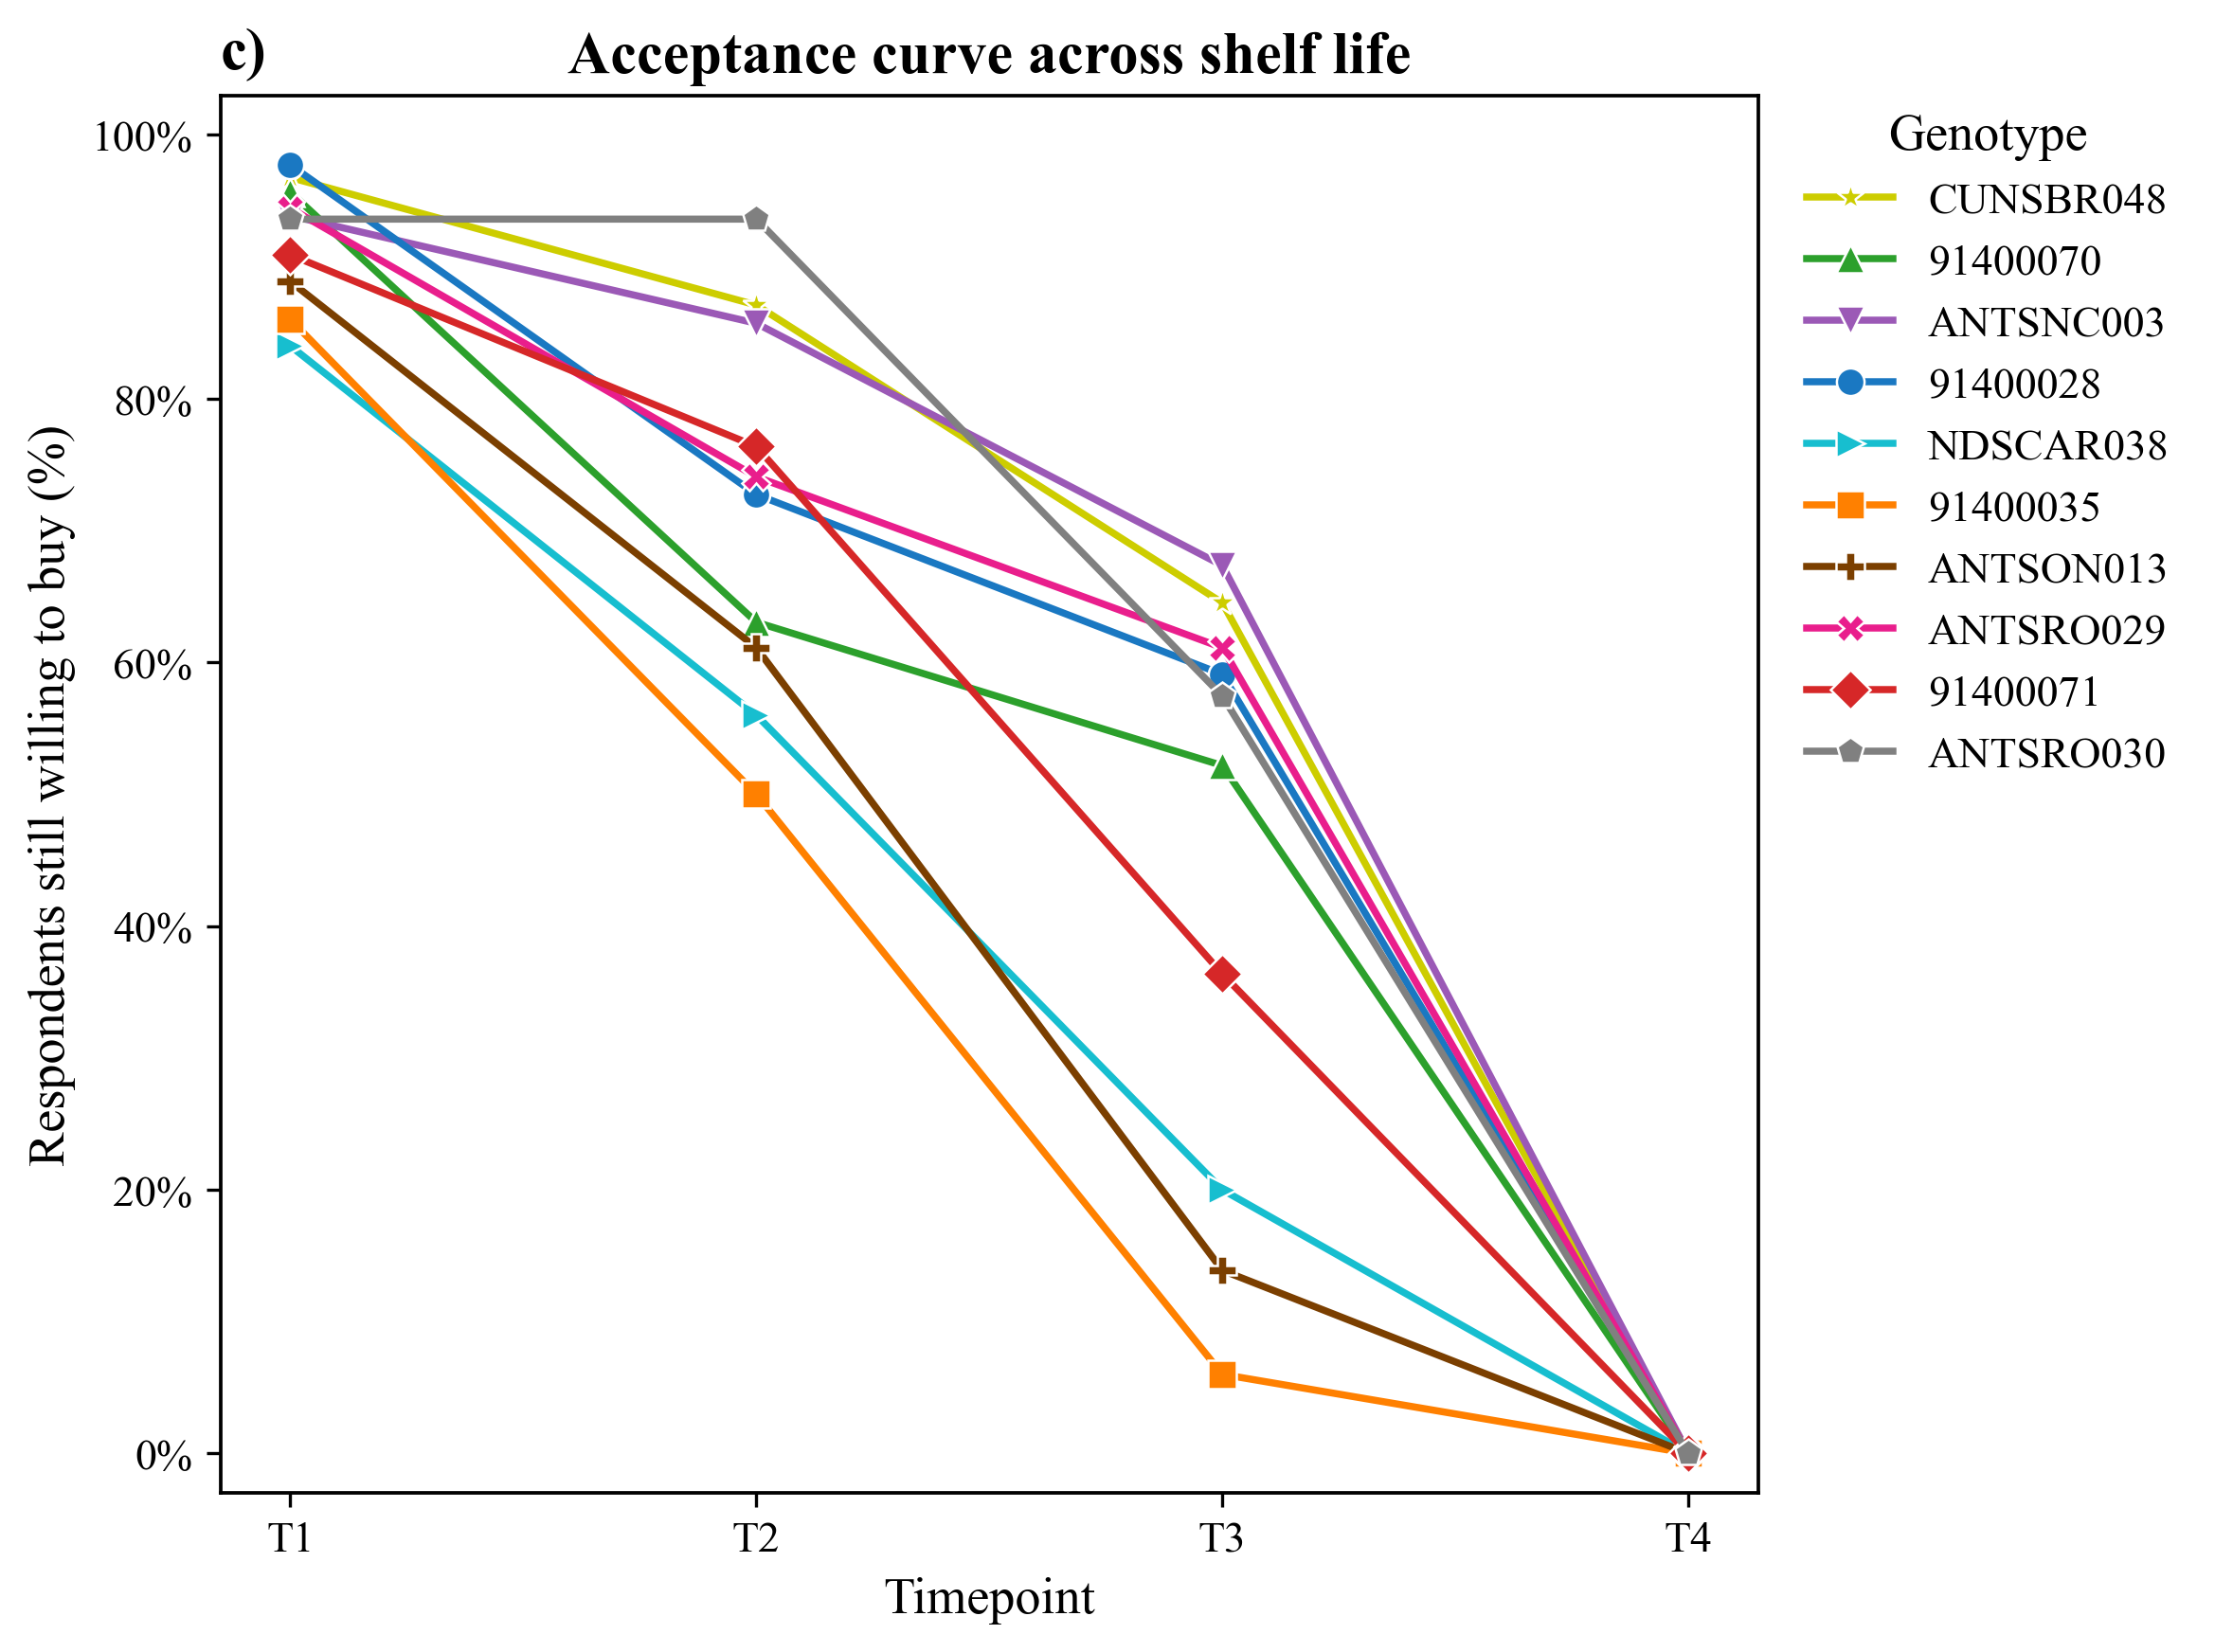

In [6]:
SHELF_LIFE_FILTER = ["Sí", "Tal vez"]
CURVE_MODE = "exclusive"
TIMEPOINTS = [1, 2, 3, 4]

curve, n_curve = acceptance_curve(df, blocks, SHELF_LIFE_FILTER, CURVE_MODE, TIMEPOINTS)
print(f"Filter: {SHELF_LIFE_FILTER}   |   Mode: {CURVE_MODE}\n")
print(curve.round(1))
print("\nn per genotype:")
print(n_curve)

fig_c, _ = plot_curve(
    curve, n_curve, TIMEPOINTS,
    title="Acceptance curve across shelf life",
    panel_label="c)",
)
plt.show()

## 8. d) Acceptance curve by direct selection per timepoint

Loads the `Preguntas en vida util` sheet, where respondents selected the materials (by index 1–10, in G order) they would buy at each timepoint. Each percentage uses as base only the respondents who answered that timepoint (unbalanced).

n per timepoint (non-null answers, unbalanced):
T1    59
T2    56
T3    54
T4    44
dtype: int64

T      T1    T2    T3    T4
G                          
G1   37.3  25.0  24.1   2.3
G2   27.1   5.4  16.7  11.4
G3   35.6  44.6  29.6  11.4
G4   25.4  28.6  38.9  15.9
G5    6.8   5.4   3.7  11.4
G6   15.3   1.8   3.7  25.0
G7   13.6   0.0   1.9   6.8
G8   71.2  44.6  59.3  79.5
G9   23.7  46.4   7.4  25.0
G10  27.1  50.0   9.3   2.3


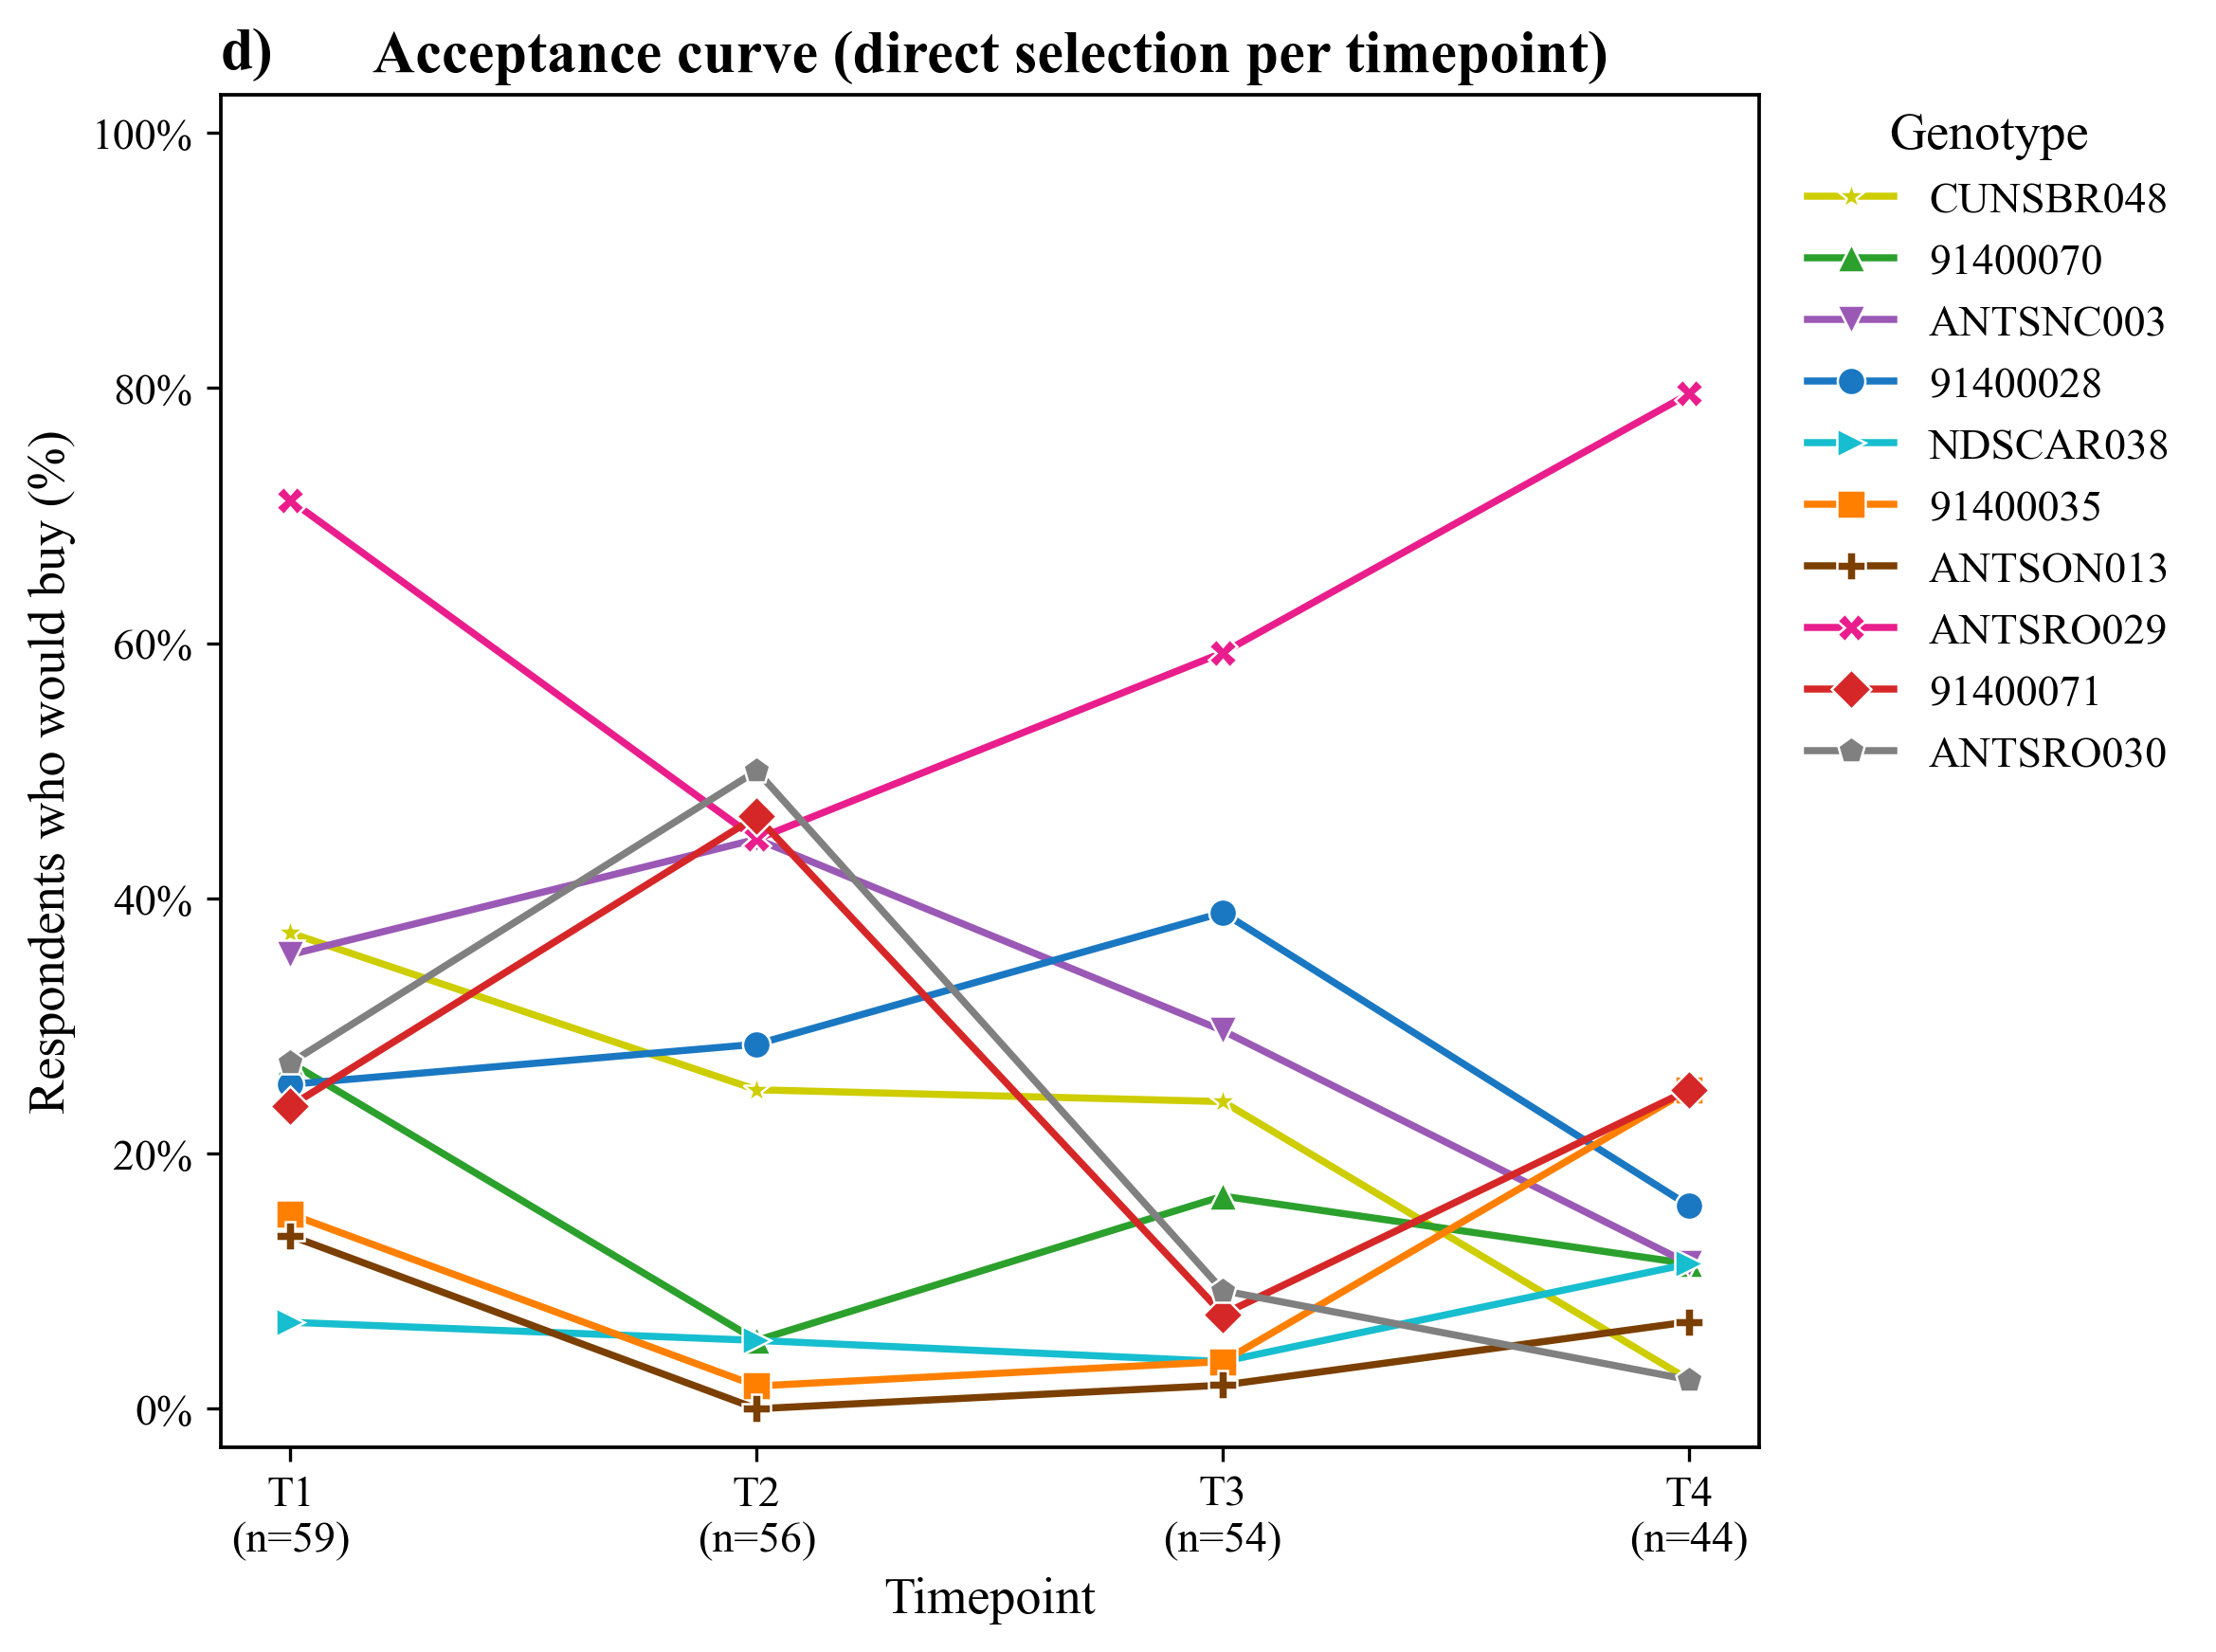

In [7]:
df_sl = pd.read_excel(SURVEY_PATH, sheet_name="Preguntas en vida util")

TIMEPOINT_COLS = {
    "T1": "What materials would you buy in T1?",
    "T2": "What materials would you buy in T2?",
    "T3": "What materials would you buy in T3?",
    "T4": "What materials would you buy in T4?",
}
INDEX_TO_G = {i + 1: g for i, g in enumerate(GENOTYPES.keys())}
G_ORDER = list(GENOTYPES.keys())


def parse_selection(value):
    """'1, 3, 8' -> [1, 3, 8]"""
    if pd.isna(value):
        return []
    return [int(x.strip()) for x in str(value).split(",") if x.strip().isdigit()]


def selection_curve(df, cols_t=TIMEPOINT_COLS, index_to_g=INDEX_TO_G):
    """Base of each %: only respondents who answered that timepoint (unbalanced)."""
    rows, ns = [], {}
    for t, col in cols_t.items():
        r = df[col].dropna()
        n = len(r)
        ns[t] = n
        selected = r.apply(parse_selection)
        for idx, g in index_to_g.items():
            pct = 100 * selected.apply(lambda lst: idx in lst).sum() / n
            rows.append({"G": g, "T": t, "pct": pct})
    table = pd.DataFrame(rows).pivot(index="G", columns="T", values="pct")
    return table.loc[G_ORDER, list(cols_t.keys())], pd.Series(ns)


def selection_curve_balanced(df, cols_t=TIMEPOINT_COLS, index_to_g=INDEX_TO_G):
    """Only respondents who answered all 4 timepoints: fixed n."""
    complete = df.dropna(subset=list(cols_t.values())).copy()
    n = len(complete)
    rows = []
    for t, col in cols_t.items():
        selected = complete[col].apply(parse_selection)
        for idx, g in index_to_g.items():
            pct = 100 * selected.apply(lambda lst: idx in lst).sum() / n
            rows.append({"G": g, "T": t, "pct": pct})
    table = pd.DataFrame(rows).pivot(index="G", columns="T", values="pct")
    return table.loc[G_ORDER, list(cols_t.keys())], n


def plot_selection_curve(curve, ns, genotypes=GENOTYPES, title=None,
                         panel_label=None, figsize=FIGSIZE, show_n=True):
    order = sorted(curve.index, key=lambda g: int(g[1:]))
    ts = list(curve.columns)

    fig, ax = plt.subplots(figsize=figsize)
    for g in order:
        info = genotypes[g]
        ax.plot(range(1, len(ts) + 1), curve.loc[g, ts].values,
                marker=info["marker"], color=info["color"],
                linewidth=1.8, markersize=7,
                markeredgecolor="white", markeredgewidth=0.6,
                label=info["genotype"])

    ax.set_xticks(range(1, len(ts) + 1))
    if show_n:
        ax.set_xticklabels([f"{t}\n(n={ns[t]})" for t in ts])
    else:
        ax.set_xticklabels(ts)
    ax.set_xlim(0.85, len(ts) + 0.15)
    ax.set_ylim(-3, 103)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.set_xlabel("Timepoint")
    ax.set_ylabel("Respondents who would buy (%)")

    if title:
        ax.set_title(title)
    if panel_label:
        ax.annotate(panel_label, xy=(0, 1.02), xycoords="axes fraction",
                    fontsize=15, fontweight="bold")

    close_axes(ax)
    legend_outside(ax, title="Genotype")
    fig.tight_layout()
    return fig, ax


curve_sl, n_sl = selection_curve(df_sl)
print("n per timepoint (non-null answers, unbalanced):")
print(n_sl)
print()
print(curve_sl.round(1))

fig_d, _ = plot_selection_curve(
    curve_sl, n_sl,
    title="Acceptance curve (direct selection per timepoint)",
    panel_label="d)",
)
plt.show()

## 9. e) Acceptance heatmap, BALANCED panel (fixed n across T1–T4)

Balanced n (answered T1-T4): 40
T      T1    T2    T3    T4
G                          
G1   40.0  32.5  27.5   2.5
G2   35.0   7.5  17.5  12.5
G3   35.0  37.5  30.0  12.5
G4   27.5  30.0  52.5  17.5
G5    7.5   7.5   5.0  12.5
G6    7.5   2.5   5.0  27.5
G7   10.0   0.0   2.5   7.5
G8   65.0  50.0  60.0  77.5
G9   25.0  50.0   5.0  25.0
G10  27.5  45.0  12.5   0.0


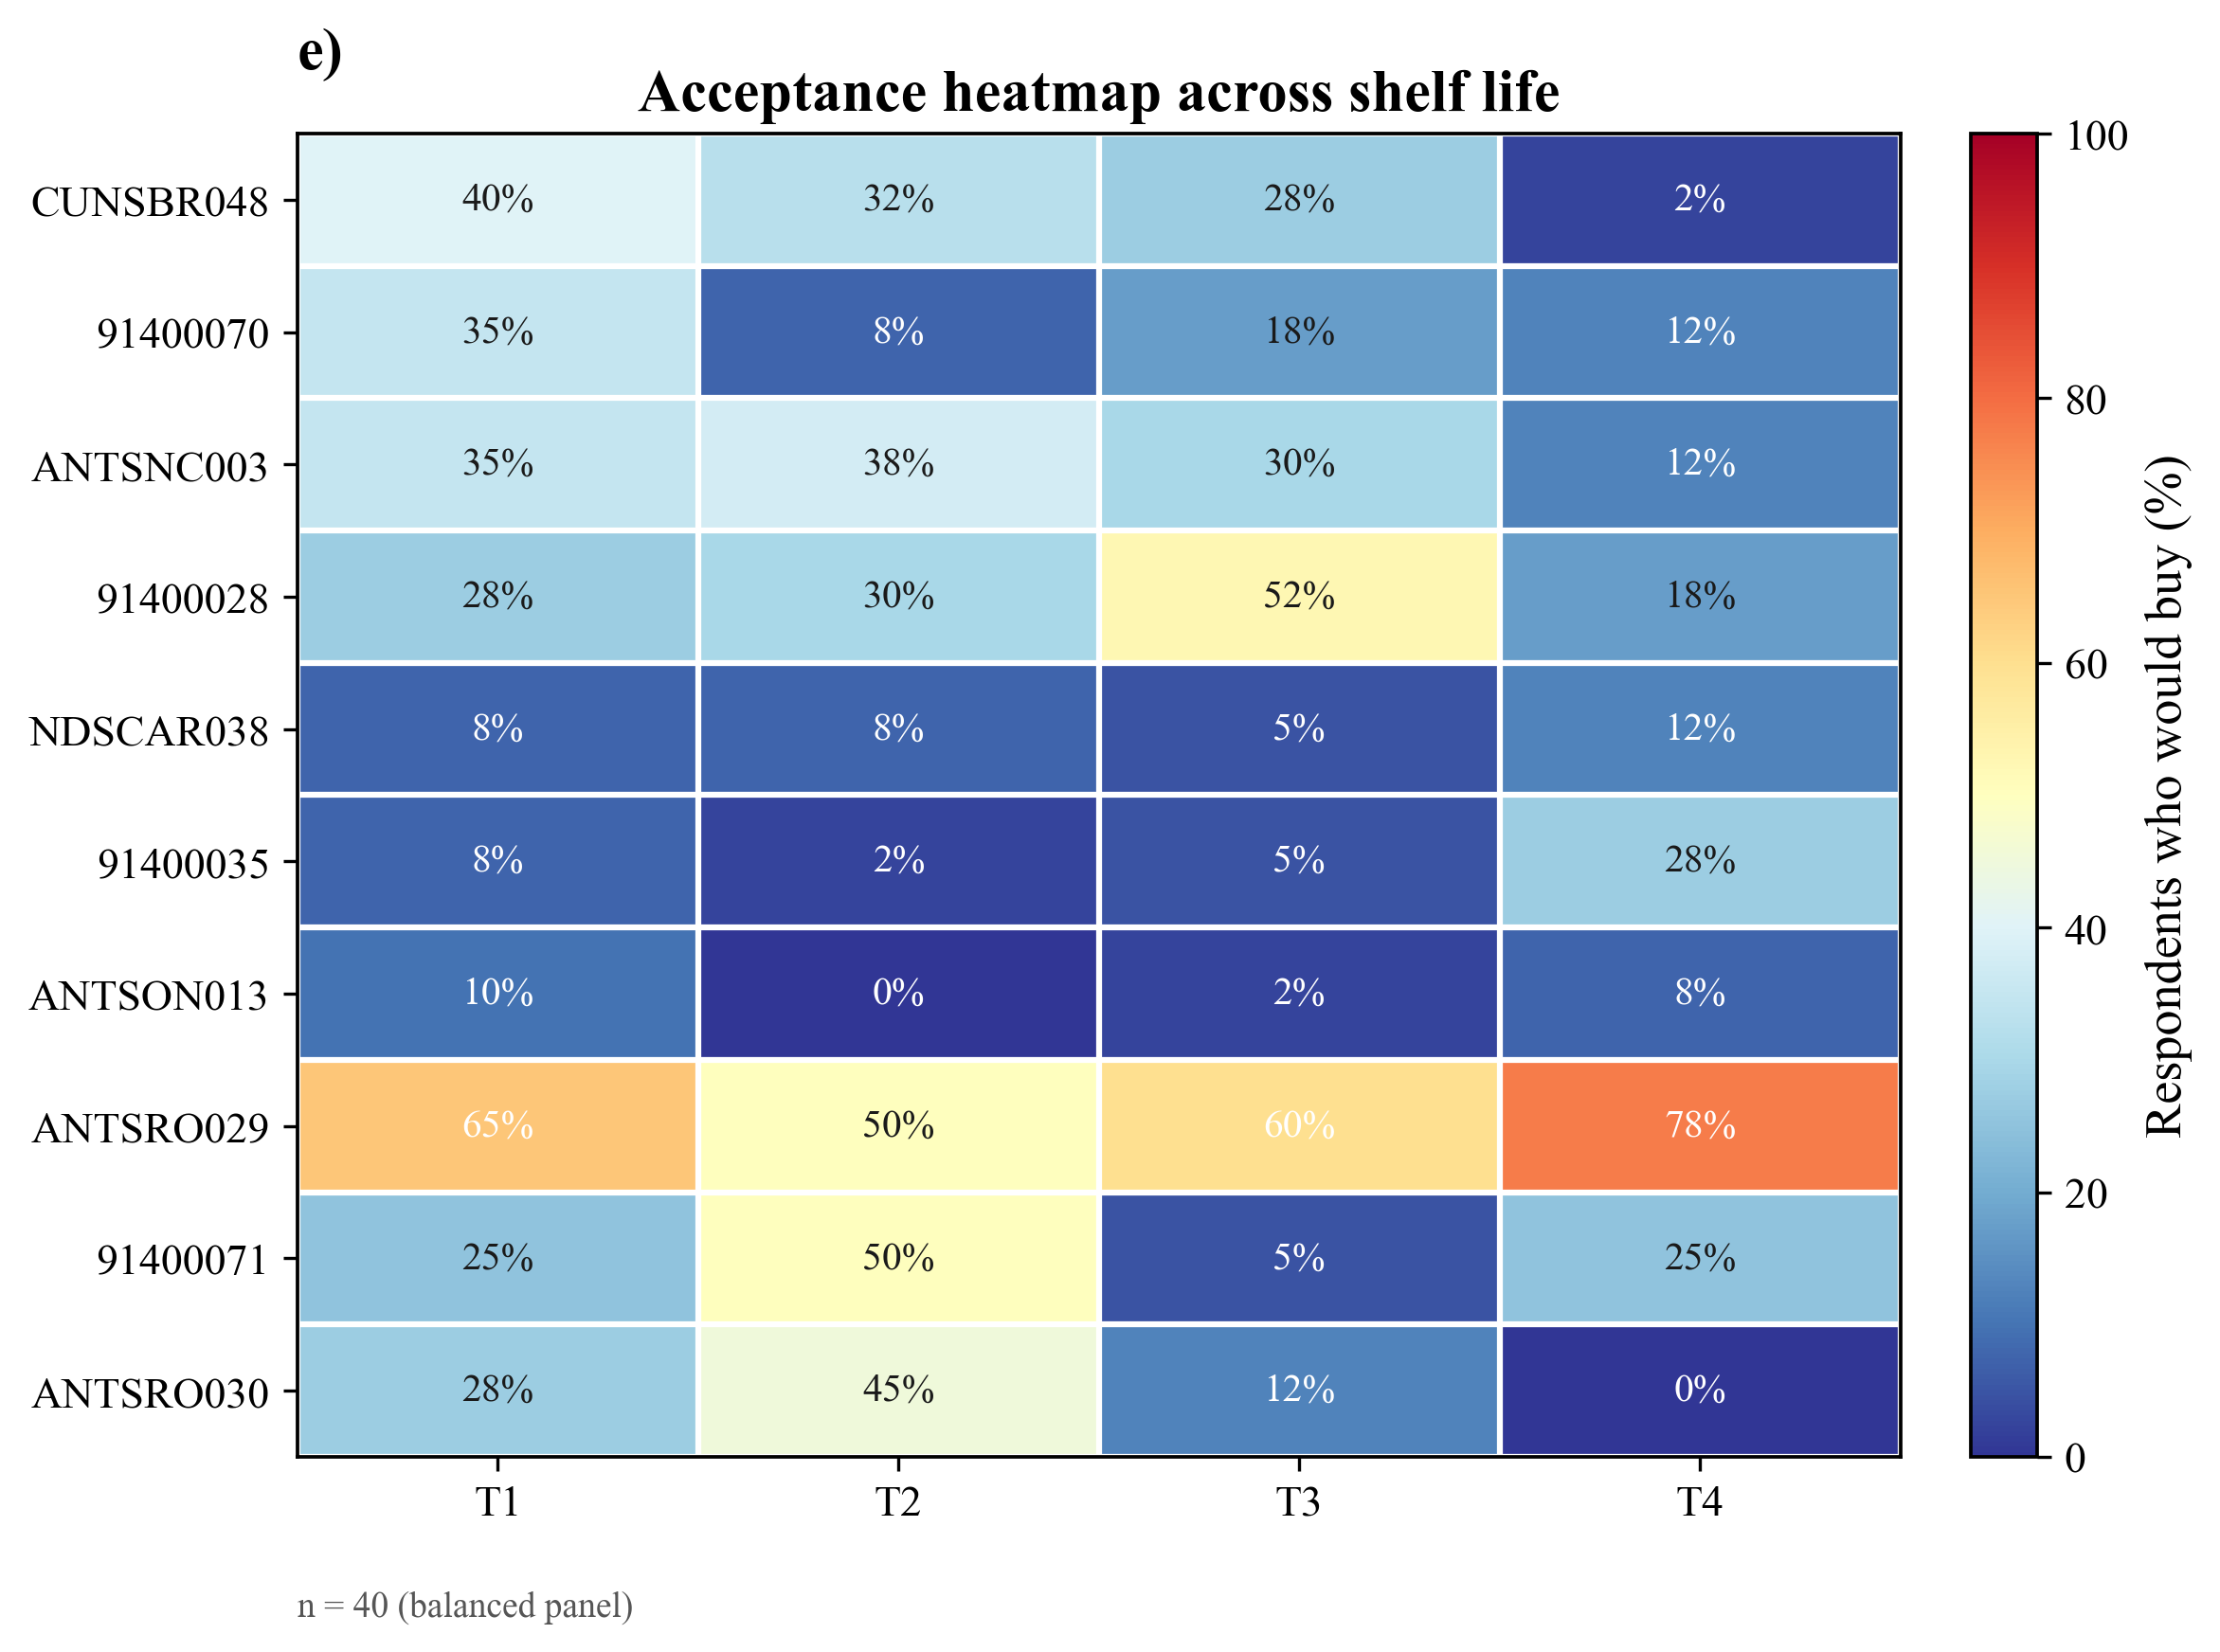

In [8]:
curve_bal, n_bal = selection_curve_balanced(df_sl)
print(f"Balanced n (answered T1-T4): {n_bal}")
print(curve_bal.round(1))


def acceptance_heatmap(curve, n, genotypes=GENOTYPES, title=None,
                       panel_label=None, cmap_name="RdYlBu_r", figsize=FIGSIZE):
    """Genotype x timepoint heatmap. Only the genotype name is shown,
    without the G1/G2/... prefix."""
    order = sorted(curve.index, key=lambda g: int(g[1:]))
    ts = list(curve.columns)
    data = curve.loc[order, ts].values
    row_labels = [genotypes[g]["genotype"] for g in order]

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(data, cmap=cmap_name, vmin=0, vmax=100, aspect="auto")

    ax.set_xticks(range(len(ts)))
    ax.set_xticklabels(ts)
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(row_labels)

    for i in range(len(order)):
        for j in range(len(ts)):
            val = data[i, j]
            text_color = "white" if val > 55 or val < 15 else "#1a1a1a"
            ax.text(j, i, f"{val:.0f}%", ha="center", va="center",
                    fontsize=10, color=text_color)

    ax.set_xticks(np.arange(-0.5, len(ts), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(order), 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.5)
    ax.tick_params(which="minor", bottom=False, left=False)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Respondents who would buy (%)")

    if title:
        ax.set_title(title)
    if panel_label:
        ax.annotate(panel_label, xy=(0, 1.05), xycoords="axes fraction",
                    fontsize=15, fontweight="bold")
    ax.annotate(f"n = {n} (balanced panel)", xy=(0.0, -0.12),
                xycoords="axes fraction", fontsize=9, color="#555555")

    fig.tight_layout()
    return fig, ax


fig_e, _ = acceptance_heatmap(
    curve_bal, n_bal,
    title="Acceptance heatmap across shelf life",
    panel_label="e)",
)
plt.show()